# Rationale: 
> Mapping between source and target vocabulary concepts. Additional function of suggestion of concept placement in target vocabulary when mapping threshold is not met. 

USE CASE: VO : RxNorm mapping
1. Phase 0: Environment Setup
    1. Elastisearch Setup
    1. FAISS Setup
    1. Source Terminology loading
    1. Target Terminology loading
1. Phase 1: SIMILARITY
    1. Lexical Similarity (BM25 Indexing)
    1. Semantic Similarity (Dense Indexing - Faiss Inner Product ~ cosine)
    1. Reciprocal Ranked Fusion of similarity scores (RRF) to generate candidates
1. Phase 2: LLM REFINEMENT
    1. The output would be either a match from the pool or 'NO MATCH'
    1. If output is 'NO MATCH' an LLM agent would take over
1. Phase 3: LLM AGENT
    1. Agent Tools
        1. Vocabulary traversal
        1. Similarity from Phase 1
    1. Agent would then suggest/place a new concept at location

# Phase 0: Environment Setup

## 0.1 Elastisearch Setup

In [3]:
from elasticsearch import Elasticsearch
from VaxMapper.src.utils.elastisearch_utils import run_elasticsearch, stop_elasticsearch, create_index, doc_actions, bulk_index

In [2]:
es_process = run_elasticsearch()
es = Elasticsearch("http://localhost:9200")

Starting Elasticsearch from /data/wmanuel3/VaxMapperRepo/esdata/elasticsearch-9.0.0/bin/elasticsearch...
Elasticsearch is running: 9.0.0


## 0.2 FAISS Setup

In [29]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'
from VaxMapper.src.utils.embedding_utils import load_ST_model, encode_texts, build_and_save_dense_index
MODEL_ID_LIST = ['tavakolih/all-MiniLM-L6-v2-pubmed-full']
                #  , 'Alibaba-NLP/gte-Qwen2-1.5B-instruct', 'google/medgemma-27b-text-it']

In [31]:
emb_model = load_ST_model(MODEL_ID_LIST[0])

Loading model tavakolih/all-MiniLM-L6-v2-pubmed-full...
Model tavakolih/all-MiniLM-L6-v2-pubmed-full loaded to cuda:0 successfully.


In [32]:
del emb_model

## 0.3 Source Terminology Loading [RxNorm]

In [5]:
from VaxMapper.src.rxnorm_term_getter import parallel_map, gather_vaccine_related_rxcuis, get_obsolete_rxcuis, get_rxnorm_status
import pandas as pd

In [6]:
rx_vax_ids= gather_vaccine_related_rxcuis()
obs_rx_ids = get_obsolete_rxcuis()

Found 581 initial RxNorm concepts
Finding related concepts (expanding via /allrelated)...
Found 2000 total RxNorm concepts after expansion
Fetching obsolete RxNorm terms...
Found 97795 obsolete RxNorm terms


In [7]:
rx_vax_df = pd.DataFrame(parallel_map(get_rxnorm_status,list(rx_vax_ids)))
obs_rx_df = pd.DataFrame(obs_rx_ids, columns=['rxcui','name','tty'])
obs_rx_df['status'] = 'Obsolete'

In [ ]:
# Think about the wrapper script (dense_ann.py) for this

In [8]:
obsolete_vecs = encode_texts(emb_model, obs_rx_df['name'].tolist(), batch_size=64, normalize=True)
rx_faiss_index = build_and_save_dense_index(df=rx_vax_df,model=emb_model,label_column='name',batch_size=64,normalize=True,save_index=False)

Batches:   0%|          | 0/1529 [00:00<?, ?it/s]

Encoding 2000 texts from column 'name'...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Index built with 2000 IDs.


In [9]:
k = 1
D, I = rx_faiss_index.search(obsolete_vecs, k)
similarity_threshold = 0.9
vaccine_like_obsolete = []

matches = []
for idx, (similarities, indices) in enumerate(zip(D, I)):
    for sim, i in zip(similarities, indices):
        if sim >= similarity_threshold:
            matches.append(obs_rx_df.iloc[idx].get("rxcui"))

In [10]:
len(matches), "matches found in obsolete_df"
ob_df = obs_rx_df[obs_rx_df['rxcui'].isin(matches)].copy()
ob_df.reset_index(drop=True, inplace=True)

In [11]:
rxnav_df = pd.concat([rx_vax_df, ob_df], ignore_index=True)
rxnav_df.to_pickle('mresults/rxnav_df.pkl')

## 0.4 Target Terminology Loading [VO]

In [4]:
from owlready2 import *

In [ ]:
vo_df = pd.DataFrame
vo = get_ontology("vo_source/VO_merged2022_10_05.owl").load()
rows = []
for cls in vo.classes():
    name = cls.name
    if name.startswith("VO_"):
        label_text = cls.label.en.first() if isinstance(cls.label.first(), locstr) else cls.label.first()
        rxcui = cls.VO_0003198.first() if hasattr(cls, 'VO_0003198') and type(cls.VO_0003198.first())==int else None
        rows.append({"vo_id": name, "label": label_text, "rxcui": rxcui})
vo_df = pd.DataFrame(rows)
vo_df = vo_df[~vo_df['label'].str.contains("obsolete", case=False, na=False)]
vo_df.to_pickle("mresults/vo_data.pkl")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
vo_df = pd.read_pickle("mresults/vo_data.pkl")

# Phase 1: SIMILARITY

## 1.1 Lexical Similarity (BM25 Indexing)

In [14]:
vo_settings = {
  "settings": {
    "analysis": {
      "filter": {
        "vaccine_syns": {                
          "type": "synonym_graph",
          "synonyms_path": "vaccine_syns.txt"
        }
      },
      "analyzer": {
        "vaccine_analyzer": {
          "tokenizer": "standard",
          "filter": ["lowercase", "asciifolding", "vaccine_syns"]
        }
      }
    },
    "similarity": {
      "bm25_short": {
        "type": "BM25",
        "k1": 0.9,
        "b":  0.4
      }
    }
  },
  "mappings": {
    "properties": {
      "vo_id":  { "type": "keyword" },        
      "iri":    { "type": "keyword" },        
      "text": {
        "type": "text",
        "analyzer":   "vaccine_analyzer",
        "similarity": "bm25_short"
      }
    }
  }
}

In [15]:
create_index(es,"vo_bm25", vo_settings)
bulk_index(es, vo_df, "vo_bm25", "vo_id", "label")

## 1.2 Semantic Similarity (Dense Indexing)

In [ ]:
# from owlready2 import *
# from typing import List, Sequence, Tuple, Optional, Callable, Union
# import numpy as np
# import faiss
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"
# import torch
# from sentence_transformers import SentenceTransformer
# import requests
# import pandas as pd
# import pickle
# import json
# import pandas as pd
# from tqdm import tqdm
# import subprocess
# import os
# import signal
# import time
# from pathlib import Path
# import time, requests, subprocess
# from pathlib import Path

Refs: 
* Analyzer [https://www.elastic.co/docs/reference/elasticsearch/mapping-reference/analyzer]
* Syns graph [https://www.elastic.co/docs/reference/text-analysis/analysis-synonym-graph-tokenfilter]
* Similarity [https://www.elastic.co/docs/reference/elasticsearch/index-settings/similarity]
* Mapping []

Todo: Apply synonyms during indexing or search ?


In [ ]:
# VO_INDEX = "vo_bm25"

# try:
#     response = es.indices.delete(index=VO_INDEX)
#     print(f"Index '{VO_INDEX}' deleted successfully: {response}")
# except Exception as e:
#     print(f"Error deleting index '{VO_INDEX}': {e}")

# vo_settings = {
#   "settings": {
#     "analysis": {
#       "filter": {
#         "vaccine_syns": {                
#           "type": "synonym_graph",
#           "synonyms_path": "vaccine_syns.txt"
#         }
#       },
#       "analyzer": {
#         "vaccine_analyzer": {
#           "tokenizer": "standard",
#           "filter": ["lowercase", "asciifolding", "vaccine_syns"]
#         }
#       }
#     },
#     "similarity": {
#       "bm25_short": {
#         "type": "BM25",
#         "k1": 0.9,
#         "b":  0.4
#       }
#     }
#   },
#   "mappings": {
#     "properties": {
#       "vo_id":  { "type": "keyword" },        
#       "iri":    { "type": "keyword" },        
#       "text": {
#         "type": "text",
#         "analyzer":   "vaccine_analyzer",
#         "similarity": "bm25_short"
#       }
#     }
#   }
# }

# es.indices.create(index=VO_INDEX, body=vo_settings, ignore=400)


#### 2. Loading RxNorm via RxNav API

#### 2.1 Helper Functions  

In [ ]:
class RateLimiter:
    def __init__(self, max_calls_per_second=5):
        self.max_calls_per_second = max_calls_per_second
        self.min_interval = 1.0 / max_calls_per_second
        self.last_called = 0
        self.lock = Lock()
    
    def wait(self):
        with self.lock:
            elapsed = time.time() - self.last_called
            left_to_wait = self.min_interval - elapsed
            if left_to_wait > 0:
                time.sleep(left_to_wait)
            self.last_called = time.time()

rate_limiter = RateLimiter(max_calls_per_second=10)

In [ ]:
def rate_limited(rate_limiter: RateLimiter):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            rate_limiter.wait()
            return func(*args, **kwargs)
        return wrapper
    return decorator

In [ ]:
def threaded_params_fetch(
    params_list: List[dict],
    # apikey: str,
    fetch_func: Callable[[dict, str], Union[dict, List[dict]]],
    desc: str = "Fetching data",
    max_workers: int = 10
):
    """
    Specialized version of threaded_umls_fetch for parameter dictionaries
    """
    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(fetch_func, params): str(params)
            for params in params_list
        }
        with tqdm(total=len(params_list), desc=desc) as pbar:
            for future in concurrent.futures.as_completed(futures):
                params_str = futures[future]
                try:
                    result = future.result()
                    if isinstance(result, list):
                        results.extend(result)
                    else:
                        results.append(result)
                    pbar.set_postfix({"Current": params_str[:50]})
                except Exception as e:
                    print(f"Error fetching {params_str}: {e}")
                pbar.update(1)
    return results

In [ ]:
# Helper functions from rxnorm_getter 
# Todo: Move them out of the identify_missing_rxnorm_terms function: 

def get_rxnorm_data(rxcui):
        result = {}
        result['rxcui'] = rxcui
        status_url = f"https://rxnav.nlm.nih.gov/REST/rxcui/{rxcui}/historystatus.json?"
        try:
            response = requests.get(status_url)
            if response.status_code == 200:
                data = response.json()
                result['name'] = data.get("rxcuiStatusHistory", {}).get("attributes", {}).get("name")
                result['status'] = data.get("rxcuiStatusHistory", {}).get("metaData", {}).get("status")
                result['tty'] = data.get("rxcuiStatusHistory", {}).get("attributes", {}).get("tty")
        except requests.RequestException as e:
            print(f"Error fetching RxNorm status for {rxcui}: {e}")
        return result

def get_class_descendants(class_id, class_type):
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxclass/classTree.json?classId={class_id}&classType={class_type}"
    descendants = []
    
    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        descendants = _collect_leaf_classids(data["rxclassTree"])
        
    except Exception as e:
        print(f"API error with {class_id}: {e}")
        
    return descendants

def _collect_leaf_classids(tree):
    leaves = []
    for node in tree:
        cid = node["rxclassMinConceptItem"]["classId"]
        cname = node["rxclassMinConceptItem"]["className"]
        children = node.get("rxclassTree")
        if children:                      
            leaves.extend(_collect_leaf_classids(children))
        else:                             
            leaves.append({'ID': cid, 'Name': cname})
    return leaves

def get_rx_class_members(params):
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxclass/classMembers.json"
    class_id = params.get("classId")
    source = params.get("relaSource")
    result = {"class_id": class_id, "source": source, "related_ids": None}
    
    try:
        response = requests.get(api_url, params=params)
        response.raise_for_status()      
        data = response.json()
        if "drugMemberGroup" in data and "drugMember" in data["drugMemberGroup"]:
            related_ids = [item["minConcept"]["rxcui"] for item in data["drugMemberGroup"]["drugMember"]]
            result["related_ids"] = related_ids
    except Exception as e:
        print(f"API error with {class_id}: {e}")

    return result

def get_related_rxcui(rxcui):
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxcui/{rxcui}/allrelated.json"
    result = {"rxcui": rxcui, "related_ids": None}

    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        concept_groups = data.get("allRelatedGroup", {}).get("conceptGroup", [])
        related_concepts = []
        for group in concept_groups:
            if "conceptProperties" in group:
                related_concepts.extend([concept.get("rxcui") for concept in group["conceptProperties"]])

        result["related_ids"] = related_concepts

    except Exception as e:
        print(f"API error with {rxcui}: {e}")

    return result

def get_all_obsolete_concepts():
    api_url = "https://rxnav.nlm.nih.gov/REST/allstatus.json?status=obsolete"
    obsolete_concepts = []

    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        concepts = data.get('minConceptGroup', {}).get('minConcept', [])
        for concept in concepts:
            rxcui = concept.get('rxcui')
            name = concept.get('name')
            tty = concept.get('tty')
            obsolete_concepts.append({
                'rxcui': rxcui,
                'name': name,
                'tty': tty
            })
        print(f"Found {len(obsolete_concepts)} obsolete concepts.")

    except Exception as e:
        print(f"API error: {e}")

    return obsolete_concepts

In [ ]:
@rate_limited(rate_limiter)
def get_rxnorm_data(rxcui: str, apikey: str) -> dict:
    """Get RxNorm data for a given RXCUI"""
    result = {}
    result['rxcui'] = rxcui
    status_url = f"https://rxnav.nlm.nih.gov/REST/rxcui/{rxcui}/historystatus.json"
    
    try:
        response = requests.get(status_url, params={'apikey': apikey} if apikey else {})
        if response.status_code == 200:
            data = response.json()
            result['name'] = data.get("rxcuiStatusHistory", {}).get("attributes", {}).get("name")
            result['status'] = data.get("rxcuiStatusHistory", {}).get("metaData", {}).get("status")
            result['tty'] = data.get("rxcuiStatusHistory", {}).get("attributes", {}).get("tty")
    except requests.RequestException as e:
        print(f"Error fetching RxNorm status for {rxcui}: {e}")
    
    return result

@rate_limited(rate_limiter)
def get_class_descendants_single(class_id: str, apikey: str, class_type: str = "ATC1-4") -> List[dict]:
    """Get descendants for a single class ID"""
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxclass/classTree.json?classId={class_id}&classType={class_type}"
    descendants = []
    
    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        descendants = _collect_leaf_classids(data["rxclassTree"])
        
    except Exception as e:
        print(f"API error with {class_id}: {e}")
        
    return descendants

@rate_limited(rate_limiter)
def get_rx_class_members_single(class_params: dict, apikey: str) -> dict:
    """Get class members for a single class"""
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxclass/classMembers.json"
    class_id = class_params.get("classId")
    source = class_params.get("relaSource")
    result = {"class_id": class_id, "source": source, "related_ids": None}
    
    try:
        response = requests.get(api_url, params=class_params)
        response.raise_for_status()      
        data = response.json()
        if "drugMemberGroup" in data and "drugMember" in data["drugMemberGroup"]:
            related_ids = [item["minConcept"]["rxcui"] for item in data["drugMemberGroup"]["drugMember"]]
            result["related_ids"] = related_ids
    except Exception as e:
        print(f"API error with {class_id}: {e}")

    return result

@rate_limited(rate_limiter)
def get_related_rxcui_single(rxcui: str, apikey: str) -> dict:
    """Get related RXCUIs for a single RXCUI"""
    api_url = f"https://rxnav.nlm.nih.gov/REST/rxcui/{rxcui}/allrelated.json"
    result = {"rxcui": rxcui, "related_ids": None}

    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        concept_groups = data.get("allRelatedGroup", {}).get("conceptGroup", [])
        related_concepts = []
        for group in concept_groups:
            if "conceptProperties" in group:
                related_concepts.extend([concept.get("rxcui") for concept in group["conceptProperties"]])

        result["related_ids"] = related_concepts

    except Exception as e:
        print(f"API error with {rxcui}: {e}")

    return result

@rate_limited(rate_limiter)
def get_all_obsolete_concepts_single(dummy_param: str, apikey: str) -> List[dict]:
    """Get all obsolete concepts (doesn't need threading but keeping consistent interface)"""
    api_url = "https://rxnav.nlm.nih.gov/REST/allstatus.json?status=obsolete"
    obsolete_concepts = []

    try:
        response = requests.get(api_url)
        response.raise_for_status()      
        data = response.json()
        concepts = data.get('minConceptGroup', {}).get('minConcept', [])
        for concept in concepts:
            rxcui = concept.get('rxcui')
            name = concept.get('name')
            tty = concept.get('tty')
            obsolete_concepts.append({
                'rxcui': rxcui,
                'name': name,
                'tty': tty
            })
        print(f"Found {len(obsolete_concepts)} obsolete concepts.")

    except Exception as e:
        print(f"API error: {e}")

    return obsolete_concepts

#### 2.2 Implementation

In [ ]:
# Collect RxNorm concepts from different sources
rx_concepts = set()

# ATC concepts - First get descendants, then get members
print("Collecting from ATC...")
atc_class_ids = ["J07"]  # Can be extended to multiple classes
atc_descendants_results = threaded_params_fetch(
    cui_list=atc_class_ids,
    # apikey=apikey,
    fetch_func=lambda class_id, api_key: get_class_descendants_single(class_id, api_key, "ATC1-4"),
    desc="Fetching ATC Descendants",
    max_workers=5
)

# Flatten descendants and get class members
atc_class_params = []
for descendants_list in atc_descendants_results:
    for atc in descendants_list:
        atc_class_params.append({"classId": atc['ID'], "relaSource": "ATCPROD"})

# Get class members for all ATC classes
if atc_class_params:
    atc_members_results = threaded_params_fetch(
        cui_list=atc_class_params,
        apikey=apikey,
        fetch_func=lambda params, api_key: get_rx_class_members_single(params, api_key),
        desc="Fetching ATC Class Members",
        max_workers=10
    )
    
    for result in atc_members_results:
        if result.get('related_ids'):
            rx_concepts.update(result['related_ids'])

# VA concepts
print("Collecting from VA...")
VA_Classes = ["IM100", "IM105", "IM109"]
rela = ["has_vaclass", "has_vaclass_extended"]
va_class_params = []
for va in VA_Classes:
    for r in rela:
        va_class_params.append({"classId": va, "relaSource": "VA", "rela": r})

va_members_results = threaded_params_fetch(
    cui_list=va_class_params,
    apikey=apikey,
    fetch_func=lambda params, api_key: get_rx_class_members_single(params, api_key),
    desc="Fetching VA Class Members",
    max_workers=10
)

for result in va_members_results:
    if result.get('related_ids'):
        rx_concepts.update(result['related_ids'])

# CVX concepts
print("Collecting from CVX...")
cvx_descendants_results = threaded_params_fetch(
    cui_list=["0"],
    apikey=apikey,
    fetch_func=lambda class_id, api_key: get_class_descendants_single(class_id, api_key, "CVX"),
    desc="Fetching CVX Descendants",
    max_workers=5
)

cvx_class_params = []
for descendants_list in cvx_descendants_results:
    for cvx in descendants_list:
        cvx_class_params.append({"classId": cvx['ID'], "relaSource": "CDC", "rela": "isa_CVX"})

if cvx_class_params:
    cvx_members_results = threaded_params_fetch(
        cui_list=cvx_class_params,
        apikey=apikey,
        fetch_func=lambda params, api_key: get_rx_class_members_single(params, api_key),
        desc="Fetching CVX Class Members",
        max_workers=10
    )
    
    for result in cvx_members_results:
        if result.get('related_ids'):
            rx_concepts.update(result['related_ids'])

# DailyMed concepts
print("Collecting from DailyMed...")
dm_classes = ["N0000193912", "D014612"]
rela = ["has_epc", "has_chemical_structure"]
dm_class_params = []
for dm in dm_classes:
    for r in rela:
        dm_class_params.append({"classId": dm, "relaSource": "DAILYMED", "rela": r})

dm_members_results = threaded_params_fetch(
    cui_list=dm_class_params,
    apikey=apikey,
    fetch_func=lambda params, api_key: get_rx_class_members_single(params, api_key),
    desc="Fetching DailyMed Class Members",
    max_workers=10
)

for result in dm_members_results:
    if result.get('related_ids'):
        rx_concepts.update(result['related_ids'])

print(f"Found {len(rx_concepts)} initial RxNorm concepts")

# Get related concepts
print("Finding related concepts...")
all_rx_list = list(rx_concepts)
related_results = threaded_params_fetch(
    cui_list=all_rx_list,
    apikey=apikey,
    fetch_func=get_related_rxcui_single,
    desc="Fetching Related RXCUIs",
    max_workers=15
)

for result in related_results:
    if result.get('related_ids'):
        all_rx_list.extend(result['related_ids'])

all_rx_final = list(set(all_rx_list))
print(f"Found {len(all_rx_final)} total RxNorm concepts after expansion")

# Get RxNorm data for all concepts
print("Pulling RxNorm data for identified terms...")
rxnav_data = threaded_params_fetch(
    cui_list=all_rx_final,
    apikey=apikey,
    fetch_func=get_rxnorm_data,
    desc="Fetching RxNorm Data",
    max_workers=15
)

rxnav_df = pd.DataFrame(rxnav_data)
rxnav_df.rename(columns={"name": "label"}, inplace=True)
rxnav_df.to_pickle("rxnav_data.pkl")
print(f"Saved {len(rxnav_df)} RxNorm records")

In [ ]:
# Collect RxNorm concepts from different sources
rx_concepts = set()

# ATC concepts
print("Collecting from ATC...")
atc_descendants = get_class_descendants("J07", "ATC1-4")
for atc in atc_descendants:
    params = {"classId": atc['ID'], "relaSource": "ATCPROD"}
    res = get_rx_class_members(params)
    if res['related_ids']:
        rx_concepts.update(res['related_ids'])

# VA concepts
print("Collecting from VA...")
VA_Classes = ["IM100", "IM105", "IM109"]
rela = ["has_vaclass", "has_vaclass_extended"]
for va in VA_Classes:
    for r in rela:
        params = {"classId": va, "relaSource": "VA", "rela": r}
        res = get_rx_class_members(params)
        if res['related_ids']:
            rx_concepts.update(res['related_ids'])

# CVX concepts
print("Collecting from CVX...")
cvx_descendants = get_class_descendants("0", "CVX")
for cvx in cvx_descendants:
    params = {"classId": cvx['ID'], "relaSource": "CDC", "rela": "isa_CVX"}
    res = get_rx_class_members(params)
    if res['related_ids']:
        rx_concepts.update(res['related_ids'])

# DailyMed concepts
print("Collecting from DailyMed...")
dm_classes = ["N0000193912", "D014612"]
rela = ["has_epc", "has_chemical_structure"]
for dm in dm_classes:
    for r in rela:
        params = {"classId": dm, "relaSource": "DAILYMED", "rela": r}
        res = get_rx_class_members(params)
        if res['related_ids']:
            rx_concepts.update(res['related_ids'])

print(f"Found {len(rx_concepts)} initial RxNorm concepts")

# Get related concepts
print("Finding related concepts...")
all_rx_list = list(rx_concepts)
count = 0
for rxcui in rx_concepts:
    res = get_related_rxcui(rxcui)
    if res['related_ids']:
        all_rx_list.extend(res['related_ids'])
    count += 1
    if count % 100 == 0:
        print(f"Processed {count}/{len(rx_concepts)} concepts...")

all_rx_final = list(set(all_rx_list))
print(f"Found {len(all_rx_final)} total RxNorm concepts after expansion")

# 5. Compare with existing VO annotations
print("Pulling RxNorm data for identified terms ...")
rxnav_data = [get_rxnorm_data(rxcui) for rxcui in all_rx_final]
rxnav_df = pd.DataFrame(rxnav_data)
print(len(rxnav_df), "rows")
# change df column "names" to "label"
rxnav_df.rename(columns={"name": "label"}, inplace=True)
rxnav_df.to_pickle("rxnav_data.pkl")

In [ ]:
rxnav_df = pd.read_pickle("rxnav_data.pkl")
rxnav_df

#### 2.3 Retrival of RxNorm Obsolete Concepts

In [ ]:
obsolete = get_all_obsolete_concepts()
obsolete_df = pd.DataFrame(obsolete)
obsolete_df['rxcui'] = obsolete_df['rxcui'].astype('Int64')
obsolete_df.rename(columns={"name": "label"}, inplace=True)

In [ ]:
model = load_model(MODEL_ID_LIST[0])

In [ ]:
# Obtaining Related Obsolete Concepts. Preliminary step using similarity. 
# ToDo: Load RxNorm DB (RXNREL) and identify related obsolete concepts
vaccine_texts = rxnav_df["label"].tolist()
obsolete_texts = obsolete_df["label"].tolist()
vaccine_vecs = encode_texts(model, vaccine_texts, batch_size=64, normalize=True)
obsolete_vecs = encode_texts(model, obsolete_texts, batch_size=64, normalize=True)
rx_faiss_ids = rxnav_df.index.to_numpy(dtype="int64")
rx_faiss_index = build_faiss_index(vaccine_vecs, ids=rx_faiss_ids, use_gpu=True)

k = 1
D, I = rx_faiss_index.search(obsolete_vecs, k)
similarity_threshold = 0.9
vaccine_like_obsolete = []

matches = []
for idx, (similarities, indices) in enumerate(zip(D, I)):
    for sim, i in zip(similarities, indices):
        if sim >= similarity_threshold:
            matches.append(obsolete_df.iloc[idx].get("rxcui"))

In [ ]:
rx_faiss_ids = build_and_save_dense_index(model,vaccine_texts,vaccine_vecs,index_name="rx_faiss_ids",save_path="rx_faiss_ids.pkl",use_gpu=True,)

In [ ]:
len(matches), "matches found in obsolete_df"
# load obsolete_df where rxcui is in matches
ob_df = obsolete_df[obsolete_df['rxcui'].isin(matches)].copy()
# add a column "status" to ob_df
ob_df['status'] = 'obsolete'
ob_df.reset_index(drop=True, inplace=True)
ob_df

####  3. Loading and preprocessing VO 

In [ ]:
vo_df = pd.DataFrame
vo = get_ontology("vo_source/VO_merged2022_10_05.owl").load()
rows = []
for cls in vo.classes():
    name = cls.name
    if name.startswith("VO_"):
        label_text = cls.label.en.first() if isinstance(cls.label.first(), locstr) else cls.label.first()
        rxcui = cls.VO_0003198.first() if hasattr(cls, 'VO_0003198') and type(cls.VO_0003198.first())==int else None
        rows.append({"vo_id": name, "label": label_text, "rxcui": rxcui})
vo_df = pd.DataFrame(rows)
# drop rows with label that contains 'obsolete'
vo_df = vo_df[~vo_df['label'].str.contains("obsolete", case=False, na=False)]
# vo_df = vo_df.fillna("")
vo_df.to_pickle("vo_data.pkl")

In [ ]:
# unpickle the dataframe
vo_df = pd.read_pickle("vo_data.pkl")

### Dense Index Setup

In [ ]:
texts = vo_df["label"].tolist()
vecs = encode_texts(model, texts, batch_size=64, normalize=True)
faiss_ids = vo_df.index.to_numpy(dtype="int64")  # Use DataFrame index as IDs
faiss_index = build_faiss_index(vecs, ids=faiss_ids, use_gpu=True)
faiss_cpu = faiss.index_gpu_to_cpu(faiss_index)
faiss.write_index(faiss_cpu, "vo_faiss.bin")

In [ ]:
build_and_save_dense_index(
    df=vo_df, 
    model=model,
    label_column="label",
    batch_size=64,
    normalize=True,
    use_gpu=True,
    save_index=True,
    index_filename="vo_faiss.bin"
)

In [ ]:
# del model, vo_vecs
# # clear cache
# torch.cuda.empty_cache()
# import gc
# gc.collect()

### BM25 Index Setup

In [ ]:
def doc_actions(df, index_name="vo_bm25"):
    """
    df columns expected: ['vo_id', 'text'].
    ToDo: One row per VO label or synonym. 
    """
    df = df.fillna("")           

    for idx, row in df.iterrows():
        yield {
            "_op_type": "index",
            "_index"  : index_name,
            "_id"     : f"{row.vo_id}-{idx}",    # unique per synonym
            "vo_id"   : row.vo_id,
            # "iri"     : row.iri,
            "text"    : row.label
        }


In [ ]:
from elasticsearch.helpers import streaming_bulk
for ok, action in streaming_bulk(
        es, doc_actions(vo_df), chunk_size=1000, max_retries=5, initial_backoff=2
):
    if not ok:
        print("Failed to index document:", action)

### Candidate Generation and Ranking

In [ ]:
def dense_candidates(faiss_index, q_vec, meta_df, k=20):
    D, I = faiss_index.search(q_vec.reshape(1,-1), k)
    rows = meta_df.loc[I[0], ["vo_id","label"]]
    rows = rows.assign(score=D[0])
    return rows.reset_index(drop=True).to_dict(orient="records")

In [ ]:
def bm25_candidates(es, rx_label: str, k: int = 20, index="vo_bm25"):
    """
    Return top-k lexical hits for a VO label from the RxNorm BM25 index.
    """
    resp = es.search(
        index=index,              # ← keyword
        size=k,                   # ← keyword
        query={                   # ← keyword
            "match": {
                "text": {         # field defined in mappings
                    "query": rx_label,
                    "operator": "or"
                }
            }
        }
    )
    return [
        {
            "vo_id": hit["_source"]["vo_id"],
            "label": hit["_source"]["text"],
            "score": hit["_score"]
        }
        for hit in resp["hits"]["hits"]
    ]

In [ ]:
# Reciprocal Rank Fusion
from itertools import chain
from collections import defaultdict

def fuse_hits_rrf(dense_hits, bm25_hits, k=20, rank_bias=60):

    # 1. sort each list by its native score (descending)
    dense_hits  = sorted(dense_hits,  key=lambda x: -x["score"])
    bm25_hits   = sorted(bm25_hits,   key=lambda x: -x["score"])

    # 2. compute RRF contribution from each list
    fused = defaultdict(lambda: {"rrf": 0.0, "origin": set()})

    for rank, hit in enumerate(dense_hits, start=1):
        key = hit["vo_id"]
        fused[key]["rrf"] += 1 / (rank_bias + rank)
        fused[key]["origin"].add("dense")
        # keep a representative label
        fused[key].setdefault("label", hit["label"])

    for rank, hit in enumerate(bm25_hits,  start=1):
        key = hit["vo_id"]
        fused[key]["rrf"] += 1 / (rank_bias + rank)
        fused[key]["origin"].add("bm25")
        fused[key].setdefault("label", hit["label"])

    # 3. turn dict -> list, sort by fused score
    fused_list = [
        {
            "vo_id": key,
            "label": val["label"],
            "fused": val["rrf"],
            "from" : ",".join(sorted(val["origin"]))   # e.g. "bm25,dense"
        }
        for key, val in fused.items()
    ]
    fused_list.sort(key=lambda x: -x["fused"])

    # 4. return top-k
    return fused_list[:k]


In [ ]:
# load the faiss index from file
faiss_cpu = faiss.read_index("vo_faiss.bin")
# load index to GPU
res = faiss.StandardGpuResources()
faiss_index = faiss.index_cpu_to_gpu(res, 0, faiss_cpu)

#### Smoke Testing

In [ ]:
# calculate cosine similarity for between two vectors
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot_product / (norm_a * norm_b)

In [ ]:
query = rxnav_df.iloc[0].label
q_vec  = encode_texts(model, [query], batch_size=64, normalize=True)[0]    
t1 = vo_df[vo_df.index==3652].label.values[0]
s_vec = encode_texts(model, [t1], batch_size=64, normalize=True)[0]
cosine_sim = cosine_similarity(s_vec, q_vec)
print(f"Cosine similarity between '{query}' and the {t1} vector: {cosine_sim:.6f}")

In [ ]:
k = 10
n = 15
# select first row of rxnavdf
query = rxnav_df.iloc[0].label
q_vec  = encode_texts(model, [query], batch_size=64, normalize=True)
dense_hits = dense_candidates(faiss_index, q_vec, vo_df, k)
lexical_hits = bm25_candidates(es, query, k)
print(f"Lexical hits for '{query}':")
candidates = fuse_hits_rrf(dense_hits, lexical_hits, k=n)
candidates

# Phase 2: LLM REFINEMENT

In [ ]:
def generate_vo_candidates_for_rxnorm(
    rxnav_df: pd.DataFrame,
    vo_df: pd.DataFrame,
    model,
    faiss_index,
    es,
    k_dense=10,
    k_lexical=10,
    n_fused=15,
    batch_size=64,
    output_jsonl_path=None
):
    """
    Generate top VO candidates for each RxNorm concept using dense + lexical retrieval + RRF.

    Parameters:
        rxnav_df (pd.DataFrame): DataFrame of RxNorm concepts with at least a 'label' column.
        vo_df (pd.DataFrame): VO terms with at least 'id' and 'label'.
        model: Embedding model (e.g., SentenceTransformer).
        faiss_index: Prebuilt FAISS index of VO embeddings.
        es: Elasticsearch/BM25 engine for lexical search.
        k_dense (int): Number of dense candidates to retrieve.
        k_lexical (int): Number of lexical candidates to retrieve.
        n_fused (int): Number of final RRF candidates to keep.
        batch_size (int): Batch size for text encoding.
        output_jsonl_path (str): Optional path to store output as JSONL.

    Returns:
        List[Dict]: One dictionary per RxNorm row, including fused candidates.
    """


    results = []
    # Batchwise encoding
    queries = rxnav_df["label"].tolist()
    query_vectors = encode_texts(model, queries, batch_size=batch_size, normalize=True)
    rxcuis = rxnav_df.get("rxcui", [f"row_{i}" for i in range(len(rxnav_df))]).tolist()

    for (query,rxcui,q_vec) in tqdm(zip(queries, rxcuis, query_vectors), total=len(queries), desc="Generating candidates"):
        dense_hits = dense_candidates(faiss_index, q_vec.reshape(1,-1), vo_df, k=k_dense)
        lexical_hits = bm25_candidates(es, query, k=k_lexical)
        fused = fuse_hits_rrf(dense_hits, lexical_hits, k=n_fused)

        entry = {
            "rxcui": rxcui,
            "label": query,
            "candidates": fused
        }

        results.append(entry)

        # Optional streaming write
        if output_jsonl_path:
            with open(output_jsonl_path, "a", encoding="utf-8") as f:
                f.write(json.dumps(entry) + "\n")

    return results


In [ ]:
res = generate_vo_candidates_for_rxnorm(
    rxnav_df=rxnav_df,
    vo_df=vo_df,
    model=model,
    faiss_index=faiss_index,
    es=es,
    k_dense=10,
    k_lexical=10,
    n_fused=15,
    output_jsonl_path="vo_candidates.jsonl"
)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import json

In [ ]:
INFERENCE_MODEL_ID = ["Qwen/Qwen2-7B-Instruct", "google/medgemma-27b-text-it"]

In [ ]:
def load_inference_model(model_id):
    print(f"Loading inference model {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        use_fast=True,
        trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True)
    print(f"Inference model {model_id} loaded successfully.")
    return model, tokenizer

In [ ]:
# MODEL_ID = "Qwen/Qwen2-7B-Instruct"
# inf_tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_ID, use_fast=True, trust_remote_code=True)
# inf_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID, 
#     torch_dtype=torch.float16, 
#     device_map="auto", 
#     trust_remote_code=True
# )

In [ ]:
# # Future ToDo: Use ingredients, TTY, included in prompt
# def build_prompt(rxnorm, vo_candidates):
#     # --- System role ---
#     sys_msg = ("""\
# You are an ontology-alignment assistant. 
# Your task is to map a RxNorm clinical drug concept to the best matching Vaccine Ontology (VO) term.

# * Always choose the **single best** match if it exists.
# * If none of the candidates is an acceptable mapping, output "NONE".
# * Return answer as **valid JSON object** matching this schema:
#   {"VO_ID": "<vo_id | NONE>", "match_type": "exact|narrow|broad|none",
#    "justification": "<max 40 words>"}"""
#     )

#     # --- User message: Source concept ---
#     header = (f"""\
# ### RxNorm concept
# RxCUI: {rxnorm["rxcui"]}
# Label: {rxnorm["label"]}
# Ingredients: {", ".join(rxnorm.get("ingredients", [])) or "None"}
# Dose Form: {rxnorm.get("dose_form", "Unknown")}
# Route: {rxnorm.get("route", "Unknown")}
# Strength: {rxnorm.get("strength", "Unknown")}"""
#     )

#     # --- VO Candidates ---
#     cand_lines = [
#         f"{i}. {c['id']} | {c['label']} | score={c['fused']:.4f} | {c.get('definition','').strip()[:100]}"
#         for i, c in enumerate(vo_candidates, 1)
#     ]

#     # --- Instructions ---
#     user_msg = (
#         header +
#         "\n\n### VO Candidates\n" + "\n".join(cand_lines) +
#         "\n\n### Instructions\n"
#         "Choose the best VO concept **by VO ID**. Focus on antigen, formulation, dose, and usage context.\n"
#         "Respond with JSON only — no code fences, no extra keys."
#     )

#     return [
#         {"role": "system", "content": sys_msg},
#         {"role": "user", "content": user_msg}
#     ]


In [ ]:
inference_model_id = INFERENCE_MODEL_ID[1]
inf_model, inf_tokenizer = load_inference_model(inference_model_id)

In [ ]:
def build_prompt(rxcui, rxlabel, vo_candidates):
    # --- System role ---
    sys_msg = ("""\
You are an ontology-alignment assistant. 
Your task is to map a RxNorm clinical drug concept to the best matching Vaccine Ontology (VO) term.

* Always choose the **single best** match if it exists.
* If none of the candidates is an acceptable mapping, output "NONE".
* Return answer as **valid JSON object** matching this schema EXACTLY:
  {"VO_ID": "<vo_id | NONE>", "match_type": "exact|narrow|broad|none",
   "justification": "<max 50 words>"}
* Do not include any other text, explanation, or code fences before or after the JSON."""
    )

    # --- User message: Source concept ---
    header = (f"""\
### RxNorm concept
RxCUI: {rxcui}
Label: {rxlabel}"""
    )

    # --- VO Candidates ---
    cand_lines = [
        f"{i}. {c['vo_id']} | {c['label']} | score={c['fused']:.4f}"
        for i, c in enumerate(vo_candidates, 1)
    ]

    # --- Instructions ---
    user_msg = (
        header +
        "\n\n### VO Candidates\n" + "\n".join(cand_lines) +
        "\n\n### Instructions\n"
        "Each candidate has a reciprocal rank fusion score derived from either embedding similarity (L2 distance) or lexical similarity (BM25). "
        "Higher scores indicate a stronger semantic match. Use this score as a guideline, but base your decision on "
        "vaccine-specific details like antigen, strain, formulation, dose, vaccine season, formulation, number of viral strains and route.\n\n"
        "Choose the best VO concept **by VO_ID**. Respond with JSON only — NO CODE FENCES, no extra keys."
)

    return [
        {"role": "system", "content": sys_msg},
        {"role": "user", "content": user_msg}
    ]


In [ ]:
# chat = build_prompt(vo_term, candidates)

# prompt_ids = inf_tokenizer.apply_chat_template(
#     chat,
#     add_generation_prompt=True,   # inserts the assistant “turn header”
#     return_tensors="pt"
# ).to(inf_model.device)

# out = inf_model.generate(
#     prompt_ids,
#     max_new_tokens=120,
#     temperature=0.1,
#     repetition_penalty=1.1,
#     do_sample=False
# )

# assistant_text = inf_tokenizer.decode(out[0][prompt_ids.shape[-1]:],
#                                   skip_special_tokens=True).strip()
# mapping = json.loads(assistant_text)

In [ ]:
# import json

# def run_mapping_inference(vo_term, candidates, inf_tokenizer, inf_model):
#     """
#     Runs LLM-based mapping inference using the given term and candidate concepts.

#     Parameters:
#         vo_term (str): The source term from VO.
#         candidates (list[dict]): Candidate terms with attributes to map against.
#         inf_tokenizer: Tokenizer compatible with the inference model.
#         inf_model: A pre-loaded HuggingFace model supporting `.generate()`.

#     Returns:
#         dict: Parsed JSON mapping result from the model's assistant response.
#     """
#     chat = build_prompt(vo_term, candidates)

#     prompt_ids = inf_tokenizer.apply_chat_template(
#         chat,
#         add_generation_prompt=True,
#         return_tensors="pt"
#     ).to(inf_model.device)

#     out = inf_model.generate(
#         prompt_ids,
#         max_new_tokens=120,
#         temperature=0.1,
#         repetition_penalty=1.1,
#         do_sample=False
#     )

#     assistant_text = inf_tokenizer.decode(
#         out[0][prompt_ids.shape[-1]:],
#         skip_special_tokens=True
#     ).strip()

#     return json.loads(assistant_text)


In [ ]:
def run_mapping_inference(rxcui, rxlabel, vo_candidates, inf_tokenizer, inf_model):
    """
    Runs LLM-based mapping inference to align an RxNorm concept with the best-matching VO term.

    Parameters:
        rxcui (str): RxCUI of the source RxNorm concept.
        rxlabel (str): Label of the source RxNorm concept.
        vo_candidates (list[dict]): Candidate VO terms with IDs, labels, definitions, and similarity scores.
        inf_tokenizer: HuggingFace tokenizer with `apply_chat_template`.
        inf_model: HuggingFace model that supports `.generate()`.

    Returns:
        dict: Parsed JSON mapping result with keys:
              - rxcui (or "NONE")
              - match_type (exact | narrow | broad | none)
              - justification (short rationale)
    """
    chat = build_prompt(rxcui, rxlabel, vo_candidates)
    text = inf_tokenizer.apply_chat_template(
        chat,
        add_generation_prompt=True,
        tokenize=False
    )
    model_inputs = inf_tokenizer([text], return_tensors="pt", padding=True).to(inf_model.device)
    if inf_tokenizer.pad_token is None:
        inf_tokenizer.pad_token = inf_tokenizer.eos_token

    generated_ids = inf_model.generate(
        model_inputs.input_ids,
        pad_token_id=inf_tokenizer.pad_token_id,
        max_new_tokens=500,
        # repetition_penalty=1.1,
        # do_sample=False
    )
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    assistant_text = inf_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    # Try to extract JSON from the response
    try:
        # First attempt: parse as-is
        return json.loads(assistant_text)
    except json.JSONDecodeError:
        # Second attempt: find JSON-like patterns with regex
        json_pattern = r'(\{.*\})'
        match = re.search(json_pattern, assistant_text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(1))
            except:
                pass
        
        # Fallback: return structured error response
        print(f"Failed to parse JSON from: {assistant_text}...")
        return {
            "VO_ID": "NONE",
            "match_type": "none",
            "justification": "Error parsing model output",
            "error": "JSONDecodeError"
        }

    # return json.loads(assistant_text)

In [ ]:
# Iterate over rxnav_df
candidates = '/data/wmanuel3/VaxMapperRepo/vo_candidates.jsonl'
# mapping = []
output_jsonl_path=f"inference_results{inference_model_id.replace('/', '_')}_1.jsonl"
i= 0
with open(candidates, 'r', encoding='utf-8') as f:
    for line in f:
        i += 1
        entry = json.loads(line)
        rxcui = entry['rxcui']
        rxlabel = entry['label']
        vo_candidates = entry['candidates']
        
        # Run inference
        result = run_mapping_inference(
            rxcui=rxcui,
            rxlabel=rxlabel,
            vo_candidates=vo_candidates,
            inf_tokenizer=inf_tokenizer,
            inf_model=inf_model
        )
        result['rxcui'] = rxcui
        result['label'] = rxlabel
        # mapping.append(result)
        with open(output_jsonl_path, 'a', encoding='utf-8') as out_f:
            out_f.write(json.dumps(result) + "\n")
        # if i == 100:
        #     break
    

In [ ]:
result

In [ ]:
vo_df[vo_df['vo_id'] == 'VO_0003824']

In [ ]:
output_jsonl_path="inference_results.jsonl"

In [ ]:
# read jsonl file into a dataframe using only VO_ID and rxcui
import pandas as pd
inference_df = pd.read_json(output_jsonl_path, lines=True)
inference_df = inference_df[['rxcui', 'VO_ID']]
inference_df.rename(columns={'VO_ID': 'vo_id'}, inplace=True)
inference_df['rxcui'] = inference_df['rxcui'].astype(int)
inference_df


In [ ]:
vo_df = pd.read_pickle("vo_data.pkl")
vo_df

In [ ]:
rxnav_df= pd.read_pickle("rxnav_data.pkl")
rxnav_df = rxnav_df[['rxcui', 'label']]
rxnav_df['rxcui'] = rxnav_df['rxcui'].astype('Int64')
rxnav_df

In [ ]:
vo_expanded_df = pd.merge(vo_df, rxnav_df, on='rxcui', how='left', suffixes=('_vo', '_rxnav'))
vo_expanded_df['exact'] = vo_expanded_df.apply(lambda x: x['label_vo'] == x['label_rxnav'], axis=1)
vo_expanded_df

In [ ]:
#check if inference_df has predicted the correct rxcui (from vo_df)
vo_df['rxcui'] = vo_df['rxcui'].astype('Int64')
merged_df = pd.merge(vo_df, inference_df, on='vo_id', how='left', suffixes=('_vo', '_inference'))
# # check if vo_id from vo_df is in VO_ID from inference_df
merged_df['correct'] = merged_df.apply(lambda x: x['rxcui_vo'] == x['rxcui_inference'], axis=1)
# # count how many correct
correct_count = merged_df['correct'].sum()
total_count = len(vo_df[vo_df['rxcui'].notnull()])
accuracy = correct_count / total_count * 100

In [ ]:
merged_df

In [ ]:
merged_df[merged_df['correct'] == True]

In [ ]:
# def evaluate_mapping_accuracy(
#     predictions: dict,
#     gold_df: pd.DataFrame,
#     top_n: int = 5
# ):
#     """
#     Evaluate Top-N accuracy of RxNorm → VO candidate predictions.

#     Parameters:
#         predictions (dict): Mapping of RxCUI → list of candidate VO dicts (with 'id' key), e.g.
#             {
#               "12345": [{"id": "VO_0001", "score": 0.93}, ...],
#               ...
#             }
#         gold_df (pd.DataFrame): DataFrame with columns ['rxcui', 'vo_id'] (ground truth).
#         top_n (int): Number of top candidates to consider for match.

#     Returns:
#         accuracy (float): Proportion of RxCUIs with a correct match in top-N.
#         matched_rxcuis (List[str]): RxCUIs that were correctly matched.
#         missed_rxcuis (List[str]): RxCUIs that were not matched.
#     """
#     gold_map = dict(zip(gold_df.rxcui.astype(str), gold_df.vo_id))

#     correct = 0
#     matched = []
#     missed = []

#     for rxcui, candidates in predictions.items():
#         gold_vo = gold_map.get(str(rxcui))
#         if not gold_vo:
#             continue  # Skip if gold mapping not available

#         top_candidate_ids = [c["id"] for c in candidates[:top_n]]
#         if gold_vo in top_candidate_ids:
#             correct += 1
#             matched.append(rxcui)
#         else:
#             missed.append(rxcui)

#     total = len(gold_map)
#     accuracy = correct / total if total > 0 else 0.0
#     return accuracy, matched, missed


In [ ]:
import json
import pandas as pd

def evaluate_topn_accuracy_from_jsonl(predictions_path, gold_df, top_n=5):
    """
    Evaluate Top-N accuracy of RxNorm → VO candidate predictions from a JSONL file.

    Parameters:
        predictions_path (str): Path to JSONL file with predictions.
        gold_df (pd.DataFrame): Gold standard with columns ['rxcui', 'vo_id'].
        top_n (int): Number of top candidates to consider for evaluation.

    Returns:
        accuracy (float): Top-N accuracy.
        matched (list[str]): RxCUIs correctly matched.
        missed (list[str]): RxCUIs not matched in top-N.
    """
    gold_map = dict(zip(gold_df.rxcui.astype(str), gold_df.vo_id))
    
    matched = []
    missed = []
    total = 0

    with open(predictions_path, 'r', encoding='utf-8') as f:
        for line in f:
            entry = json.loads(line)
            rxcui = str(entry['rxcui'])
            predicted_vo_ids = [cand['vo_id'] for cand in entry['candidates'][:top_n]]

            if rxcui in gold_map:
                total += 1
                if gold_map[rxcui] in predicted_vo_ids:
                    matched.append(rxcui)
                else:
                    missed.append(rxcui)

    accuracy = len(matched) / total if total else 0.0
    return accuracy, matched, missed


In [ ]:
gold_df = pd.read_pickle("vo_data.pkl")
accuracy, matched, missed = evaluate_topn_accuracy_from_jsonl('vo_candidates.jsonl', gold_df, top_n=5)
print(f"Top-5 Accuracy: {accuracy:.2%}")
print(f"Matched: {len(matched)} | Missed: {len(missed)}")

In [ ]:
print(f"Accuracy of VO inference: {accuracy:.2f}% ({correct_count}/{total_count})") 

### 4. Combined Pipeline and Evaluation: 

In [ ]:
#Evaluation of hybrid mappings (embedding + BM25 candidates)
# open vo_candidates.jsonl and read it into a dataframe
vo_candidates_df = pd.read_json(candidates, lines=True)
vo_candidates_df = vo_candidates_df.explode('candidates')
vo_candidates_df['vo_id'] = vo_candidates_df['candidates'].apply(lambda x: x['vo_id'])
vo_candidates_df

In [ ]:
vo_df['rxcui'] = vo_df['rxcui'].astype('Int64')
merged_can_df = pd.merge(vo_df, vo_candidates_df, on='vo_id', how='left', suffixes=('_vo', '_candidates'))
merged_can_df['correct'] = merged_can_df.apply(lambda x: x['rxcui_vo'] == x['rxcui_candidates'], axis=1)
correct_by_vo = merged_can_df.groupby('vo_id')['correct'].any().reset_index()
correct_count = correct_by_vo['correct'].sum()
total_count = len(vo_df[vo_df['rxcui'].notnull()])
accuracy = correct_count / total_count * 100
print(f"Accuracy of VO inference: {accuracy:.2f}% ({correct_count}/{total_count})") 

In [1]:
## About the direction of the new concept placement: depends on the context. 

In [ ]:
correct_by_vo

# Phase 3: AGENTIC WORKFLOW

### 0. Loading ontology as NetworkX graph

In [2]:
from owlready2 import *

In [3]:
import networkx as nx
vo = get_ontology("vo_source/VO_merged2022_10_05.owl").load()
def get_ontology_graph(vo):
    G = nx.DiGraph()
    for cls in vo.classes():
        if cls.is_a:  # has parents
            for parent in cls.is_a:
                if isinstance(parent, owlready2.ThingClass):
                    G.add_edge(parent.name, cls.name)
    return G
vo_graph = get_ontology_graph(vo)

In [ ]:
# SAMPLE
# {"
# rxcui": "1244205", "# label": "0.5 ML diphtheria toxoid vaccine, inactivated 50 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML Injection", "
# candidates": [
# {"
    #n vo_id": "VO_0015015", "label": "0.5 ML Haemophilus influenzae type b strain 1482, capsular polysaccharide inactivated tetanus toxoid conjugate vaccine 0.068 MG/ML Injection", "fused": 0.01639344262295082, "from": "dense"}, {"
    !!#y vo_id": "VO_0015022", "label": "0.5 ML diphtheria toxoid vaccine, inactivated 4 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML Injection [Tenivac]", "fused": 0.01639344262295082, "from": "bm25"}, {"
    #n vo_id": "VO_0015016", "label": "Haemophilus influenzae type b, capsular polysaccharide inactivated tetanus toxoid conjugate vaccine Injection", "fused": 0.016129032258064516, "from": "dense"}, {"
    !!#y vo_id": "VO_0015023", "label": "0.5 ML diphtheria toxoid vaccine, inactivated 4 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML Prefilled Syringe [Tenivac]", "fused": 0.016129032258064516, "from": "bm25"}, {"
    #n vo_id": "VO_0003276", "label": "0.5 ML Varicella-Zoster Virus Vaccine Live (Oka-Merck) strain 2700 UNT/ML Injection", "fused": 0.015873015873015872, "from": "dense"}, {"
    !!#y vo_id": "VO_0015027", "label": "diphtheria toxoid vaccine, inactivated 4 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML [Tenivac]", "fused": 0.015873015873015872, "from": "bm25"}, {
    #n vo_id": "VO_0003272", "label": "0.65 ML Varicella-Zoster Virus Vaccine Live (Oka-Merck) strain 29800 UNT/ML Injection", "fused": 0.015625, "from": "dense"}, {"
    #n vo_id": "VO_0003996", "label": "Bordetella pertussis filamentous hemagglutinin vaccine, inactivated 0.016 MG/ML / Bordetella pertussis pertactin vaccine, inactivated 0.005 UNT/ML / Bordetella pertussis toxoid vaccine, inactivated 0.016 MG/ML / diphtheria toxoid vaccine, inactivated 5 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML [Boostrix]", "fused": 0.015625, "from": "bm25"}, {"
    #n vo_id": "VO_0003280", "label": "0.65 ML Varicella-Zoster Virus Vaccine Live (Oka-Merck) strain 29800 UNT/ML Injection", "fused": 0.015384615384615385, "from": "dense"}, {"
    #n vo_id": "VO_0003456", "label": "diphtheria toxoid vaccine, inactivated 50 UNT/ML", "fused": 0.015384615384615385, "from": "bm25"}, {"
    #n vo_id": "VO_0003262", "label": "0.5 ML Hepatitis B Surface Antigen Vaccine 0.02 MG/ML Injection", "fused": 0.015151515151515152, "from": "dense"}, {"
    #n vo_id": "VO_0003990", "label": "Bordetella pertussis filamentous hemagglutinin vaccine, inactivated 0.05 MG/ML / Bordetella pertussis pertactin vaccine, inactivated 0.016 MG/ML / Bordetella pertussis toxoid vaccine, inactivated 0.05 MG/ML / diphtheria toxoid vaccine, inactivated 50 UNT/ML / tetanus toxoid vaccine, inactivated 20 UNT/ML [Infanrix]", "fused": 0.015151515151515152, "from": "bm25"}, {"
    #n vo_id": "VO_0003427", "label": "0.5 ML Hepatitis B Surface Antigen Vaccine 0.01 MG/ML Injection", "fused": 0.014925373134328358, "from": "dense"}, {"
    #n vo_id": "VO_0003385", "label": "tetanus toxoid vaccine, inactivated 10 UNT/ML", "fused": 0.014925373134328358, "from": "bm25"}, {"
    #n vo_id": "VO_0003234", "label": "0.5 ML Hepatitis B Surface Antigen Vaccine 0.04 MG/ML Injection", "fused": 0.014705882352941176, "from": "dense"}
#]
#}

# {
# "VO_ID": "NONE",
# "match_type": "none",
# "justification": "No direct match for diphtheria toxoid and tetanus toxoid vaccine combination with specified concentration and volume.",
#  "rxcui": "1244205",
#  "label": "0.5 ML diphtheria toxoid vaccine, inactivated 50 UNT/ML / tetanus toxoid vaccine, inactivated 10 UNT/ML Injection"
#}

### 1. Tools for Agent

In [9]:
from itertools import combinations
from collections import deque

In [10]:

def get_all_ancestors(graph, node_id):
    """Helper function to get an ordered list of ancestors for a node."""
    ancestors = set()
    # Initialize a queue for the BFS, starting with the immediate parents
    nodes_to_visit = deque(graph.predecessors(node_id))
    
    # Keep track of nodes we've already added to the queue to avoid redundant processing
    visited = set(nodes_to_visit)

    while nodes_to_visit:
        current_node = nodes_to_visit.popleft()
        ancestors.add(current_node)
        
        # Find all parents of the current node
        for parent in graph.predecessors(current_node):
            if parent not in visited:
                visited.add(parent)
                nodes_to_visit.append(parent)
                
    return list(ancestors)

In [ ]:
# def score_cluster(graph, lca, cluster_nodes):
#     """Calculates a score for a cluster based on size and proximity to the LCA."""
#     size = len(cluster_nodes)
#     if size <= 1:
#         return 0

#     total_distance = 0
#     for node in cluster_nodes:
#         try:
#             # nx.shortest_path_length is from source to target, so LCA is the target
#             distance = nx.shortest_path_length(graph, source=node, target=lca)
#             total_distance += distance
#         except nx.NetworkXNoPath:
#             # If no path, this pair is invalid, add a penalty distance
#             total_distance += 10 # Penalty
            
#     avg_distance = total_distance / size if size > 0 else 1
    
#     # Score heavily favors size, and is penalized by average distance.
#     # Adding 1 to avg_distance to prevent division by zero for direct children.
#     score = (size ** 2) / (avg_distance + 1)
#     return score

# def identify_concept_clusters(graph, candidate_ids):
#     """
#     Identifies and scores clusters of concepts based on their lowest common ancestor.

#     Args:
#         graph (nx.DiGraph): The ontology graph.
#         candidate_ids (list): A list of concept IDs from the retrieval phase.

#     Returns:
#         list: A sorted list of dictionaries, each representing a scored cluster.
#     """
#     # Ensure candidates are valid nodes in the graph
#     valid_candidates = [node for node in candidate_ids if graph.has_node(node)]
    
#     # Group candidates by their lowest common ancestor
#     lca_groups = {}
#     for node1, node2 in combinations(valid_candidates, 2):
#         try:
#             # nx.lowest_common_ancestor is efficient for this
#             lca = nx.lowest_common_ancestor(graph, node1, node2)
#             if lca:
#                 if lca not in lca_groups:
#                     lca_groups[lca] = set()
#                 lca_groups[lca].add(node1)
#                 lca_groups[lca].add(node2)
#         except nx.NetworkXError:
#             # This can happen if nodes are in disconnected components
#             continue
            
#     # Score each identified cluster
#     scored_clusters = []
#     for lca, nodes in lca_groups.items():
#         cluster_score = score_cluster(graph, lca, list(nodes))
#         if cluster_score > 0:
#             scored_clusters.append({
#                 "lca": lca,
#                 "cluster_nodes": list(nodes),
#                 "score": cluster_score
#             })
            
#     # Sort clusters by score in descending order
#     return sorted(scored_clusters, key=lambda x: x['score'], reverse=True)

In [55]:
def score_cluster_with_similarity(
    graph: nx.DiGraph, 
    lca: str, 
    cluster_nodes: list[str], 
    candidate_scores: dict[str, float]
) -> float:

    size = len(cluster_nodes)
    if size <= 1:
        return 0

    # --- 1. Calculate Structural Score ---
    total_distance = 0
    content_score = 0
    print(f"Scoring cluster for LCA: {lca}")
    for node in cluster_nodes:
        print(f"  Node: {node}")
        try:
            distance = nx.shortest_path_length(graph, source=lca, target=node)
            # weighted_distance_score = distance * candidate_scores.get(node, 0)
            weighted_content_score = candidate_scores.get(node, 0) / distance if distance > 0 else candidate_scores.get(node, 0)
            content_score += weighted_content_score
            total_distance += distance
            # weight = candidate_scores.get(node, 0)
            # print(f"Node: {node}, Distance: {distance}, Weight: {weight}")
            # # total_weight += weight
            # total_weight += (weight/distance)
            # # total_distance += weighted_distance
        except nx.NetworkXNoPath:
            total_distance += 10  # Penalty for disconnected 
            
    avg_distance = total_distance / size
    # to avoid single hierarchical clusters
    if avg_distance < 1:
        print(f"Avg distance too small ({avg_distance}), returning 0 score.")
        return 0

    structural_score = size / (avg_distance)
    content_score = sum(candidate_scores.get(node, 0) for node in cluster_nodes)/ size
    final_score = structural_score * content_score

    
    # --- 3. Final Score ---
    # final_score = structural_score * content_score
    print(f"LCA: {lca}, Size: {size}, structural score: {structural_score:.4f}, content score : {content_score:.4f}, Avg Distance: {avg_distance:.2f}, Final Score: {final_score:.4f}")
    return final_score

In [56]:
def identify_concept_clusters_with_similarity(
    graph: nx.DiGraph, 
    candidates_with_scores: dict[str, float],
    min_lca_depth: int = 7 # max depth to prevent very general concepts
) -> list[dict]:

    candidate_ids = list(candidates_with_scores.keys())
    valid_candidates = [node for node in candidate_ids if graph.has_node(node)]

    # find root node
    roots = [node for node, in_degree in graph.in_degree() if in_degree == 0]
    
    lca_groups = {}
    for node1, node2 in combinations(valid_candidates, 2):
        try:
            lca = nx.lowest_common_ancestor(graph, node1, node2)
            if lca:
                lca_groups.setdefault(lca, set()).update([node1, node2])
        except nx.NetworkXError:
            continue
            
    scored_clusters = []
    for lca, nodes in lca_groups.items():
        print(f"Evaluating cluster with LCA: {lca}")
        try: 
            lca_depth = min(nx.shortest_path_length(graph, source=r, target=lca) for r in roots if nx.has_path(graph, r, lca))
            print(f"LCA {lca} depth from root: {lca_depth}")
            if lca_depth < min_lca_depth:
                print(f"Skipping LCA {lca} due to shallow depth ({lca_depth})")
                continue
        except (nx.NetworkXNoPath, ValueError):
            print(f"Skipping LCA {lca} due to no path from roots")
            continue

        cluster_score = score_cluster_with_similarity(graph, lca, list(nodes), candidates_with_scores)
        if cluster_score > 0:
            cluster_nodes_with_scores = {node: candidates_with_scores.get(node) for node in nodes}
            scored_clusters.append({
                "lca": lca,
                "cluster_nodes": cluster_nodes_with_scores,
                "score": cluster_score
            })
            
    return sorted(scored_clusters, key=lambda x: x['score'], reverse=True)

In [ ]:
# ToDo: Find a way to; 
1. remove clusters with avg distance less than 1 and 
2. dont cluster on vaccine node


In [13]:
candidates = [
    "VO_0015015",
    "VO_0015022",
    "VO_0015016",
    "VO_0015023",
    "VO_0003276",
    "VO_0015027",
    "VO_0003272",
    "VO_0003996",
    "VO_0003280",
    "VO_0003456",
    "VO_0003262",
    "VO_0003990",
    "VO_0003427",
    "VO_0003385",
    "VO_0003234"]
scores = [
0.01639344262295082,
0.01639344262295082,
0.016129032258064516,
0.016129032258064516,
0.015873015873015872,
0.015873015873015872,
0.015625,
0.015625,
0.015384615384615385,
0.015384615384615385,
0.015151515151515152,
0.015151515151515152,
0.014925373134328358,
0.014925373134328358,
0.014705882352941176]

cand_score = dict(zip(candidates, scores))

In [41]:
clusters = identify_concept_clusters(vo_graph, candidates)

In [57]:
clusters = identify_concept_clusters_with_similarity(vo_graph, cand_score)

Evaluating cluster with LCA: VO_0000165
LCA VO_0000165 depth from root: 7
Scoring cluster for LCA: VO_0000165
  Node: VO_0015015
  Node: VO_0015022
  Node: VO_0003385
  Node: VO_0003996
  Node: VO_0003456
  Node: VO_0015023
  Node: VO_0015027
  Node: VO_0003990
  Node: VO_0015016
LCA: VO_0000165, Size: 9, structural score: 1.6875, content score : 0.0158, Avg Distance: 5.33, Final Score: 0.0266
Evaluating cluster with LCA: VO_0015016
LCA VO_0015016 depth from root: 12
Scoring cluster for LCA: VO_0015016
  Node: VO_0015015
  Node: VO_0015016
Avg distance too small (0.5), returning 0 score.
Evaluating cluster with LCA: VO_0000001
LCA VO_0000001 depth from root: 6
Skipping LCA VO_0000001 due to shallow depth (6)
Evaluating cluster with LCA: VO_0000102
LCA VO_0000102 depth from root: 10
Scoring cluster for LCA: VO_0000102
  Node: VO_0015023
  Node: VO_0015027
  Node: VO_0015022
LCA: VO_0000102, Size: 3, structural score: 1.8000, content score : 0.0161, Avg Distance: 1.67, Final Score: 0.029

In [58]:
clusters

[{'lca': 'VO_0003421',
  'cluster_nodes': {'VO_0003234': 0.014705882352941176,
   'VO_0003427': 0.014925373134328358,
   'VO_0003262': 0.015151515151515152},
  'score': 0.044782770638784684},
 {'lca': 'VO_0003279',
  'cluster_nodes': {'VO_0003272': 0.015625,
   'VO_0003280': 0.015384615384615385},
  'score': 0.031009615384615385},
 {'lca': 'VO_0000102',
  'cluster_nodes': {'VO_0015023': 0.016129032258064516,
   'VO_0015027': 0.015873015873015872,
   'VO_0015022': 0.01639344262295082},
  'score': 0.029037294452418726},
 {'lca': 'VO_0000732',
  'cluster_nodes': {'VO_0015022': 0.01639344262295082,
   'VO_0003996': 0.015625,
   'VO_0015023': 0.016129032258064516,
   'VO_0015027': 0.015873015873015872,
   'VO_0003990': 0.015151515151515152},
  'score': 0.028275716394837985},
 {'lca': 'VO_0000165',
  'cluster_nodes': {'VO_0015015': 0.01639344262295082,
   'VO_0015022': 0.01639344262295082,
   'VO_0003385': 0.014925373134328358,
   'VO_0003996': 0.015625,
   'VO_0003456': 0.015384615384615385

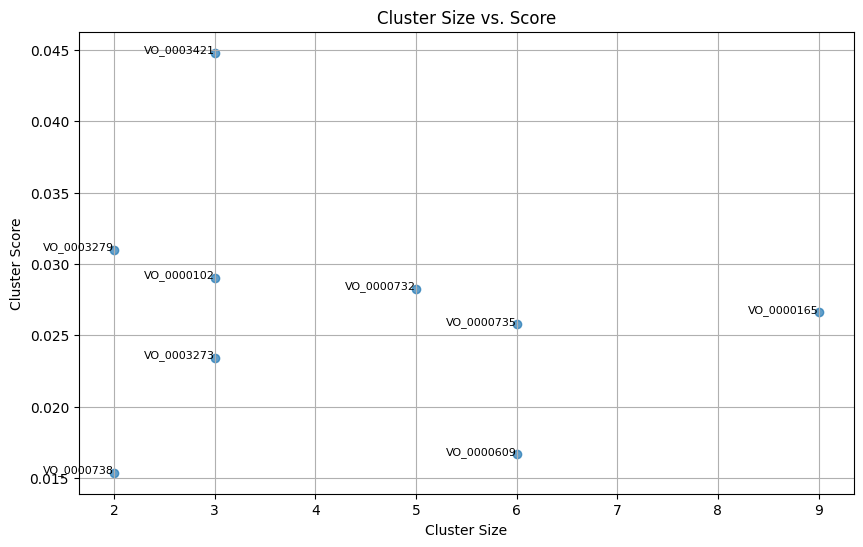

In [59]:
# plot the score and size of each cluster. Add labels to each point with the lca. order by size ascending
import matplotlib.pyplot as plt
sizes = [len(c['cluster_nodes']) for c in clusters]
scores = [c['score'] for c in clusters]
lcas = [c['lca'] for c in clusters]

# Combine the data and sort by size
data = list(zip(sizes, scores, lcas))
data.sort(key=lambda x: x[0])  # Sort by size

# Unzip the sorted data
sizes, scores, lcas = zip(*data)

# Plotting
plt.figure(figsize=(10, 6))
scatter = plt.scatter(sizes, scores, alpha=0.7)

# Add labels to each point with the LCA
for i, lca in enumerate(lcas):
    plt.annotate(lca, (sizes[i], scores[i]), fontsize=8, ha='right')

plt.title("Cluster Size vs. Score")
plt.xlabel("Cluster Size")
plt.ylabel("Cluster Score")
plt.grid(True)
plt.show()

In [ ]:
from langchain.agents import initialize_agent
from langchain.tools import Tool

# tools = [
#     Tool(
#         name="search",
#         func=search,
#         description="Search for information"
#     ),
#     Tool(
#         name="lookup",
#         func=lookup,
#         description="Look up information"
#     )
# ]

# agent = initialize_agent(tools)

<!-- Evaluation of existing mapping -
Evaluation of new mapping (between version) 
Evaluation of missing concept mapping -  -->

In [ ]:
# Testing of the general (Cell line ontology)
# missing is-a relationships
